In [1]:
import numpy as np
from scipy.stats import ks_2samp
from scipy import stats
from scipy import stats
import matplotlib.pyplot as plt
import h5py
import illustris_python as il
import sys
sys.path.append('../../py_files/')
#import weights
import control_sample as control
import BRAHMA_python as il_brahma
from tqdm import tqdm

import host_galaxy_enhancement_plots as hostplot
import host_utils as utils 
from astropy.cosmology import Planck15
from astropy import units as u

In [2]:
import arepo_package as arepo

In [3]:
import scienceplots
plt.style.use(['science'])
import os
tex_path = '/apps/texlive/2023/bin/x86_64-linux/'
os.environ['PATH'] += os.pathsep + tex_path

In [4]:

pop_file_path = '/home/pranavsatheesh/host_galaxies/data/population_files/' 
tng_pop_file_path = '/home/pranavsatheesh/host_galaxies/data/population_files/'

print("For TNG50:")
TNG_basepath = '/orange/lblecha/IllustrisTNG/Runs/TNG50-1/output'
TNG_50_pop = control.load_pop_file(TNG_basepath,tng_pop_file_path,[0,0,1000,1])
TNG_50_control = control.control_samples_TNG(TNG_50_pop,max_Mstar_tolerance=0.15,max_z_tolerance=0.1)
TNG_color = '#d95f02'


brahma_basepath="/orange/lblecha/aklantbhowmick/GAS_BASED_SEED_MODEL_UNIFORM_RUNS/L12p5n512/AREPO/"
brahma_simName_array = ['SM5_TNG','SM5_LW10_TNG','SM5_DFD_3_TNG','SM5_LW10_DFD_3_TNG','SM5_LW10_LOWSPIN_TNG','SM5_LW10_LOWSPIN_RICH_TNG']
brahma_sim_colors = {
    brahma_simName_array[0]: '#bdc9e1', 
    brahma_simName_array[1]: '#67a9cf', 
    brahma_simName_array[2]: '#1c9099', 
    brahma_simName_array[3]: '#016c59',
    brahma_simName_array[4]: '#3690c0', 
    brahma_simName_array[5]: '#014636'  
}
brahma_sim_obj = {}
brahma_sim_zbins = {}
#brahma_sim_zbin_width = {}
for i,sim in enumerate(brahma_simName_array):
    print(sim)
    simPath = brahma_basepath + sim + '/'
    brahma_pop_Nstar10 = control.load_pop_file(simPath,pop_file_path,[10,10,10,1])
    if brahma_simName_array[i] == 'SM5_LW10_LOWSPIN_RICH_TNG':
        brahma_control = control.control_sample_brahma(brahma_pop_Nstar10,max_Mstar_tolerance=0.6,max_z_tolerance=0.2)
    else:
        brahma_control = control.control_sample_brahma(brahma_pop_Nstar10,max_Mstar_tolerance=0.15,max_z_tolerance=0.2)
    brahma_sim_obj[sim] = brahma_control
    #brahma_sim_zbin_width,brahma_sim_zbins[sim] =hostplot.find_best_z_width(brahma_control.z_merging_pop,z_min=0,z_max=10,z_width_initial=0.2)
    brahma_sim_zbins[sim] = hostplot.find_adaptive_z_bins(brahma_control.z_merging_pop,z_min=0,z_max=12,zbin_width=0.3,min_N_values=10)


TNG_50_zbins = hostplot.find_adaptive_z_bins(TNG_50_control.z_merging_pop,z_min=0,z_max=10,zbin_width=0.3,min_N_values=50)
print('TNG50',TNG_50_zbins )
brahma_zbins = hostplot.find_brahma_adaptive_z_bins(brahma_sim_obj,brahma_simName_array,z_lower=0,z_max=10,zbin_width=0.1,min_N_values=10)
print('Brahma common zbins:',brahma_zbins)


sim_names = brahma_simName_array + ['TNG50']
sim_colors = {sim: brahma_sim_colors[sim] for sim in brahma_simName_array}
sim_colors['TNG50'] = TNG_color
sim_objs = brahma_sim_obj
sim_objs['TNG50'] = TNG_50_control
sim_zbins_list = brahma_sim_zbins
#sim_zbins_list = {sim: brahma_zbins for sim in brahma_simName_array}
sim_zbins_list['TNG50'] = TNG_50_zbins

For TNG50:


finding controls:   0%|          | 0/504 [00:00<?, ?it/s]

finding controls: 100%|██████████| 504/504 [00:28<00:00, 17.65it/s] 
/home/pranavsatheesh/host_galaxies/notebooks/paper_results/../../py_files/control_sample.py:411: RuntimeWarning: invalid value encountered in divide
  self.sBHAR_control_pop = self.Mdot_control_pop/self.MBH_control_pop


Number of available mergers in this population is 504
Number of cases where a close enough match is not found within the acceptable tolerance: 16
SM5_TNG


finding controls: 100%|██████████| 773/773 [00:00<00:00, 26509.11it/s]
/home/pranavsatheesh/host_galaxies/notebooks/paper_results/../../py_files/control_sample.py:705: RuntimeWarning: invalid value encountered in divide
  self.sBHAR_control_pop = self.Mdot_control_pop/self.MBH_control_pop
/home/pranavsatheesh/host_galaxies/notebooks/paper_results/../../py_files/control_sample.py:709: RuntimeWarning: invalid value encountered in divide
  self.sBHAR_control_massive_pop = self.Mdot_massive_control_pop/self.MBH_massive_control_pop
/home/pranavsatheesh/host_galaxies/notebooks/paper_results/../../py_files/control_sample.py:712: RuntimeWarning: invalid value encountered in divide
  self.sBHAR_control_luminous_pop = self.Mdot_luminous_control_pop/self.MBH_luminous_control_pop


...

Number of cases where a close enough match is not found within the acceptable tolerance: 228
number of processable mergers with valid controls:
574
[40, 36, 51, 55, 62, 79, 78, 49, 18, 11]
SM5_LW10_LOWSPIN_TNG


finding controls: 100%|██████████| 488/488 [00:00<00:00, 27176.80it/s]


Number of cases where a close enough match is not found within the acceptable tolerance: 123
number of processable mergers with valid controls:
356
[27, 21, 21, 35, 28, 58, 45, 26, 24, 16, 10]
SM5_LW10_LOWSPIN_RICH_TNG


finding controls: 100%|██████████| 175/175 [00:00<00:00, 26473.46it/s]


Number of cases where a close enough match is not found within the acceptable tolerance: 25
number of processable mergers with valid controls:
149
[11, 12, 25, 20, 11, 11, 12, 10]
[55, 56, 54, 63, 65, 55, 68, 51]
TNG50 [0.  0.3 0.6 0.9 1.3 1.7 2.1 2.6 4.5]
Brahma common zbins: [0.  0.2 0.8 1.5 2.2 3.1 4.1 5.1 7.1]


In [5]:
t_delays = utils.find_merger_time_delays(sim_objs,sim_names)

## sSFR and sBHAR enhancements for td < 0.5 Gyr

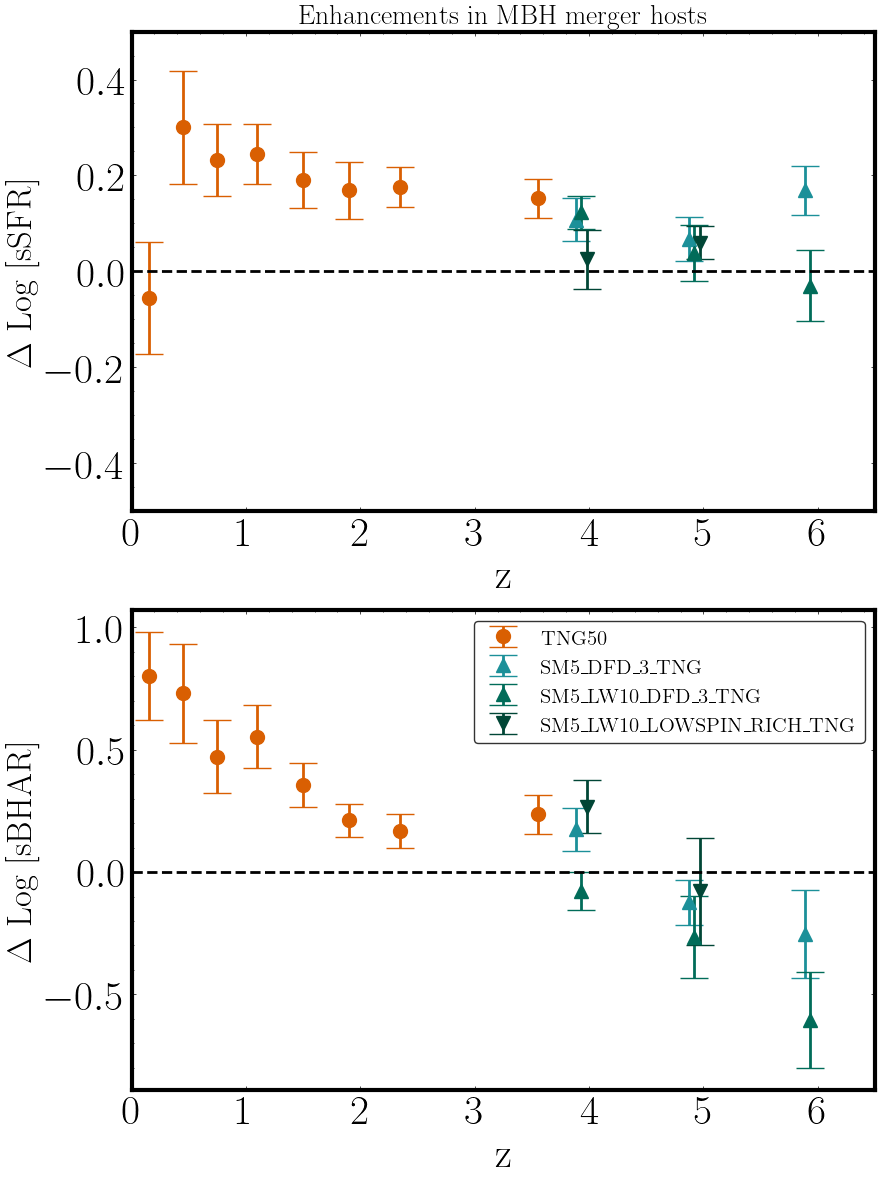

In [9]:
hostplot.set_plot_style(spinewidth=3,linewidth=3, titlesize=20,labelsize=25,xlabelsize=30,ylabelsize=30,legendsize=15,bold=True)

# Create figure with 1x2 subplots
fig, axes = plt.subplots(2,1, figsize=(9,12))

z_offset_left = 0.05
i = 0
# Plot TNG50
avg_sSFR, std_sSFR = utils.merger_enhancement_calc(sim_objs['TNG50'], 'sSFR', sim_zbins_list['TNG50'], log=True)
z_mid = sim_zbins_list['TNG50'][:-1] + np.diff(sim_zbins_list['TNG50']) / 2

axes[0].errorbar(z_mid, avg_sSFR, yerr=std_sSFR, fmt='o', capsize=10, markersize=10, 
               label='TNG50', color=sim_colors['TNG50'], alpha=1, linewidth=2)
brahma_plot_array = ['SM5_DFD_3_TNG','SM5_LW10_DFD_3_TNG','SM5_LW10_LOWSPIN_RICH_TNG']
#plot BRAHMA sims
for sim in brahma_plot_array:
    marker = '^' if 'DFD' in sim else 'v'  # Use square for DFD, circle otherwise
    unique_z, avg_sSFR, std_sSFR = utils.merger_enhancement_calc_for_small_td(
        sim, sim_objs, t_delays, min_count=10,td_threshold=0.5, quantity='sSFR'
    )
    axes[0].errorbar(
        unique_z + (i - 2.5) * z_offset_left, avg_sSFR, yerr=std_sSFR,
        fmt=marker, capsize=10, markersize=10, 
        label=sim, color=sim_colors[sim], alpha=1, linewidth=2
    )
    i += 1

axes[0].set_xticks([0, 1, 2, 3, 4, 5, 6])
axes[0].set_xlim(0,6.5)
axes[0].set_ylim(-0.5,0.5)
axes[0].axhline(0, ls='--', color='black', linewidth=2)
axes[0].set_ylabel('$\Delta$ Log [sSFR]')
axes[0].set_xlabel('z',fontsize=30)
axes[0].set_title('Enhancements in MBH merger hosts')
#axes[0].legend(frameon=True, edgecolor='black')


z_offset_left = 0.05
i = 0
# Plot TNG50
avg_sBHAR, std_sBHAR = utils.merger_enhancement_calc(sim_objs['TNG50'], 'sBHAR', sim_zbins_list['TNG50'], log=True)
z_mid = sim_zbins_list['TNG50'][:-1] + np.diff(sim_zbins_list['TNG50']) / 2

axes[1].errorbar(z_mid, avg_sBHAR, yerr=std_sBHAR, fmt='o', capsize=10, markersize=10, 
               label='TNG50', color=sim_colors['TNG50'], alpha=1, linewidth=2)

i=0
#plot BRAHMA sims
brahma_plot_array = ['SM5_DFD_3_TNG','SM5_LW10_DFD_3_TNG','SM5_LW10_LOWSPIN_RICH_TNG']
for sim in brahma_plot_array:
    marker = '^' if 'DFD' in sim else 'v'  # Use square for DFD, circle otherwise

    if 'DFD' in sim:
        unique_zs,avg_sBHAR,std_sBHAR = utils.SBHAR_enhancement_calc_for_small_td(sim,sim_objs,t_delays,min_count=10,td_threshold=0.5,type='massive')
        axes[1].errorbar(
            unique_zs + (i - 2.5) * z_offset_left, avg_sBHAR, yerr=std_sBHAR,
            fmt='^', capsize=10, markersize=10, 
            label=sim, color=sim_colors[sim], alpha=1, linewidth=2
        )

    else:
        unique_z, avg_sBHAR, std_sBHAR = utils.merger_enhancement_calc_for_small_td(
            sim, sim_objs, t_delays, min_count=10,td_threshold=0.5, quantity='sBHAR'
        )
        axes[1].errorbar(
            unique_z + (i - 2.5) * z_offset_left, avg_sBHAR, yerr=std_sBHAR,
            fmt=marker, capsize=10, markersize=10, 
            label=sim, color=sim_colors[sim], alpha=1, linewidth=2
        )   
    i += 1

axes[1].axhline(0, ls='--', color='black', linewidth=2)
axes[1].set_ylabel('$\Delta$ Log [sBHAR]')
axes[1].set_xlabel('z',fontsize=30)
axes[1].set_xticks([0, 1, 2, 3, 4, 5, 6])
axes[1].set_xlim(0,6.5)
#axes[1].set_title('TNG50 + BRAHMA ($t_{\mathrm delay} < 0.5$ Gyr)')
axes[1].legend(frameon=True, edgecolor='black')
# fig.suptitle('Merger enhancements in TNG50 and BRAHMA MBH merger hosts')
fig.tight_layout()
#fig.savefig("../../figures/sSFR_and_sBHAR_enhancements_w_z.pdf")

## sSFR vs stellar mass + sBHAR vs BH mass at low-z

/home/pranavsatheesh/host_galaxies/notebooks/paper_results/../../py_files/host_utils.py:378: RuntimeWarning: divide by zero encountered in divide
  quantity_enhancement = merging_pop_quantity / control_pop_quantity


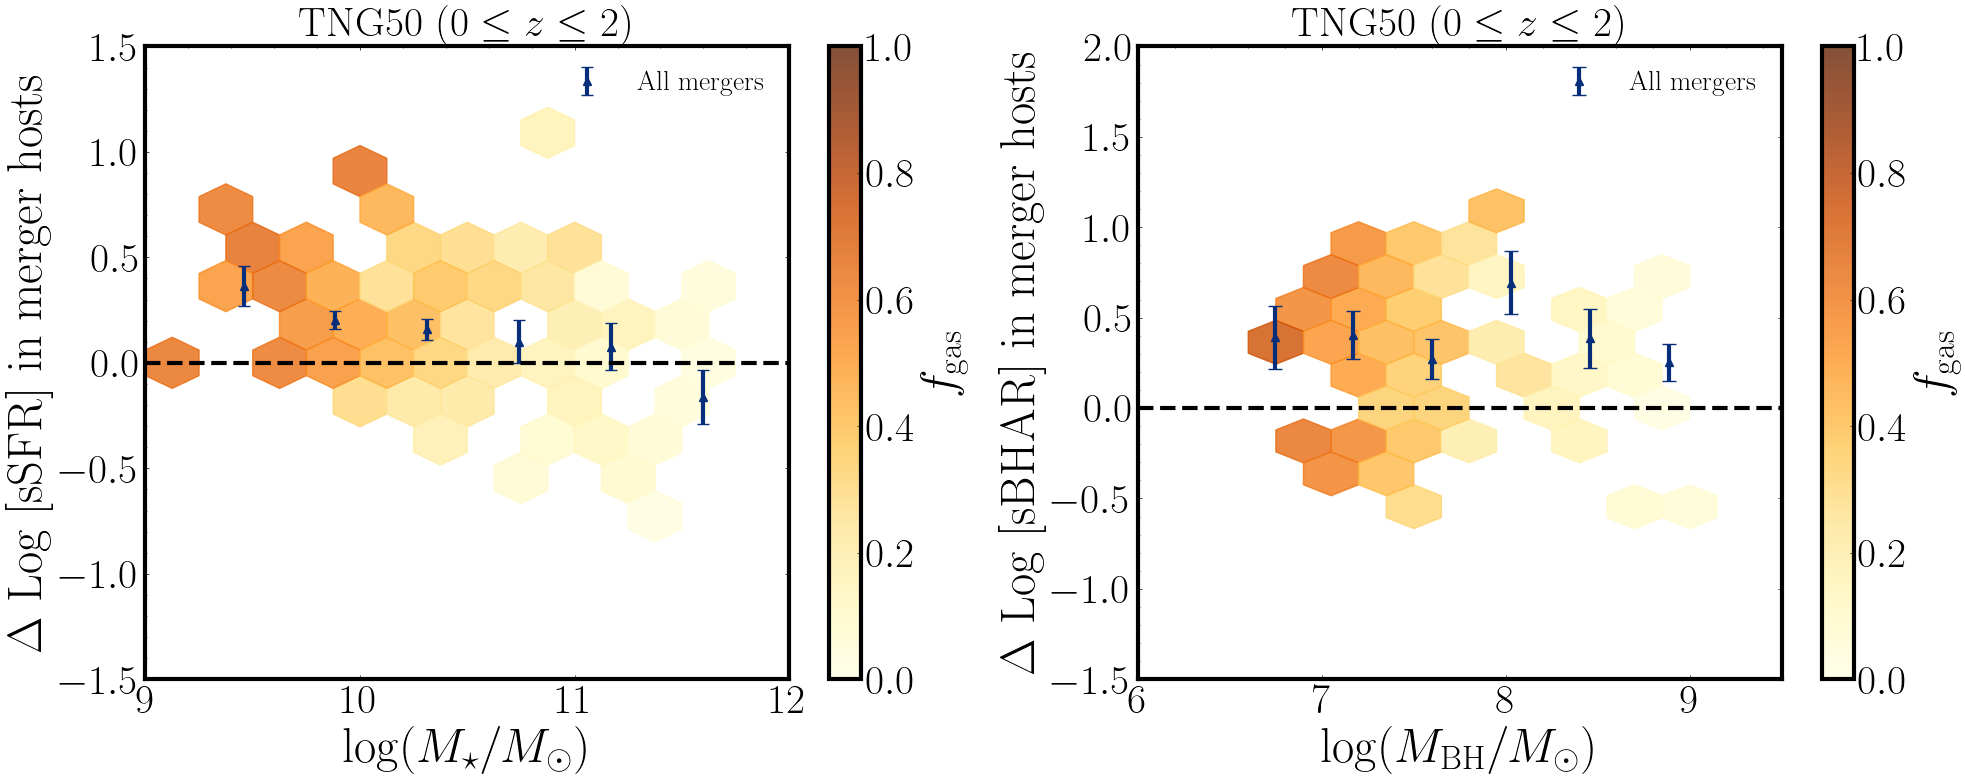

In [65]:
hostplot.set_plot_style(spinewidth=3,linewidth=3, titlesize=30,labelsize=35,xlabelsize=30,ylabelsize=30,legendsize=20,bold=True)

fig,ax = plt.subplots(1,2,figsize=(20,8))

log_Mstar_bins = np.linspace(7,13,15)

sim='TNG50'
z_offset = 0.05
c_major = "#7a0177"   # orange
c_minor = "#c51b8a"   # red
c_all  = "#062e7a"  # purple
#avg_sSFR_major,std_sSFR_major = utils.enhancement_vs_mstar_for_z(ax,sim_objs[sim],'sSFR',10**log_Mstar_bins,zlow=0,zupper=2,log=True,major_merger_flag=True,min_N=4)
#avg_sSFR_minor,std_sSFR_minor = utils.enhancement_vs_mstar_for_z(ax,sim_objs[sim],'sSFR',10**log_Mstar_bins,zlow=0,zupper=2,log=True,minor_merger_flag=True,min_N=6)
avg_sSFR_all,std_sSFR_all = utils.enhancement_vs_mstar_for_z(ax,sim_objs[sim],'sSFR',10**log_Mstar_bins,zlow=0,zupper=2,log=True,min_N=10)

#ax[0] = make_hex_plot_quantity_vs_stellar_mass(ax[0],sim_objs[sim],quantity='sSFR',zlow=0,zupper=2,gridsize=25,cmap='Blues',xmin=8,xmax=12,ymin=-2,ymax=2,mincnt=1,alpha=0.8)
ax[0] = utils.make_hex_plot_quantity_vs_stellar_mass(
    ax[0], sim_objs[sim], quantity='sSFR', zlow=0, zupper=2,
    gridsize=20, cmap='YlOrBr', xmin=7, xmax=12, ymin=-2, ymax=2,
    mincnt=3, alpha=0.8, color_quantity='fgas',vmin=0,vmax=1
)

#ax[0].errorbar(log_Mstar_bins[:-1]+np.diff(log_Mstar_bins)/2,     avg_sSFR_major, yerr=std_sSFR_major, fmt='o', capsize=4, label='Major mergers', color=c_major, alpha=1)
#ax[0].errorbar(log_Mstar_bins[:-1]+np.diff(log_Mstar_bins)/2+z_offset, avg_sSFR_minor, yerr=std_sSFR_minor, fmt='s', capsize=4, label='Minor mergers', color=c_minor, alpha=1)
ax[0].errorbar(log_Mstar_bins[:-1]+np.diff(log_Mstar_bins)/2+2*z_offset, avg_sSFR_all, yerr=std_sSFR_all, fmt='^', capsize=4, label='All mergers', color=c_all, alpha=1)
ax[0].set_xlabel(r'$\log(M_{\star}/M_{\odot})$')
ax[0].axhline(0,ls='--',color='black')
ax[0].set_ylabel('$\Delta$ Log [sSFR] in merger hosts')
ax[0].set_xlim(9,12)
ax[0].set_ylim(-1.5,1.5)
ax[0].legend()
ax[0].set_title(f'{sim} ($0\leq z\leq2)$')

log_MBH_bins = np.linspace(6,12,15)

#avg_sBHAR_major,std_sBHAR_major = utils.enhancement_vs_mbh_for_z(ax,sim_objs[sim],'sBHAR',10**log_MBH_bins,zlow=0,zupper=2,log=True,major_merger_flag=True,min_N=4)
#avg_sBHAR_minor,std_sBHAR_minor = utils.enhancement_vs_mbh_for_z(ax,sim_objs[sim],'sBHAR',10**log_MBH_bins,zlow=0,zupper=2,log=True,minor_merger_flag=True,min_N=6)
avg_sBHAR_all,std_sBHAR_all = utils.enhancement_vs_mbh_for_z(ax,sim_objs[sim],'sBHAR',10**log_MBH_bins,zlow=0,zupper=2,log=True,min_N=10)

ax[1] = utils.make_hex_plot_quantity_vs_black_hole_mass(
    ax[1], sim_objs[sim], quantity='sBHAR', zlow=0, zupper=2,
    gridsize=20, cmap='YlOrBr', xmin=6, xmax=12, ymin=-2, ymax=2,
    mincnt=3, alpha=0.8, color_quantity='fgas',vmin=0,vmax=1
)

#ax[1].errorbar(log_MBH_bins[:-1]+np.diff(log_MBH_bins)/2,     avg_sBHAR_major, yerr=std_sBHAR_major, fmt='o', capsize=4, label='Major mergers', color=c_major, alpha=1)
#ax[1].errorbar(log_MBH_bins[:-1]+np.diff(log_MBH_bins)/2+z_offset, avg_sBHAR_minor, yerr=std_sBHAR_minor, fmt='s', capsize=4, label='Minor mergers', color=c_minor, alpha=1)
ax[1].errorbar(log_MBH_bins[:-1]+np.diff(log_MBH_bins)/2+2*z_offset, avg_sBHAR_all, yerr=std_sBHAR_all, fmt='^', capsize=5, label='All mergers', color=c_all, alpha=1)
ax[1].set_xlabel(r'$\log(M_{\rm BH}/M_{\odot})$')
ax[1].axhline(0,ls='--',color='black')
ax[1].set_ylabel('$\Delta$ Log [sBHAR] in merger hosts')
ax[1].set_xlim(6,9.5)
ax[1].set_ylim(-1.5,2)
ax[1].legend()
ax[1].set_title(f'{sim} ($0\leq z\leq2)$')

fig.tight_layout()
fig.savefig("../../figures/sSFR_and_sBHAR_enhancements_vs_Mstar_and_MBH_TNG50.pdf")

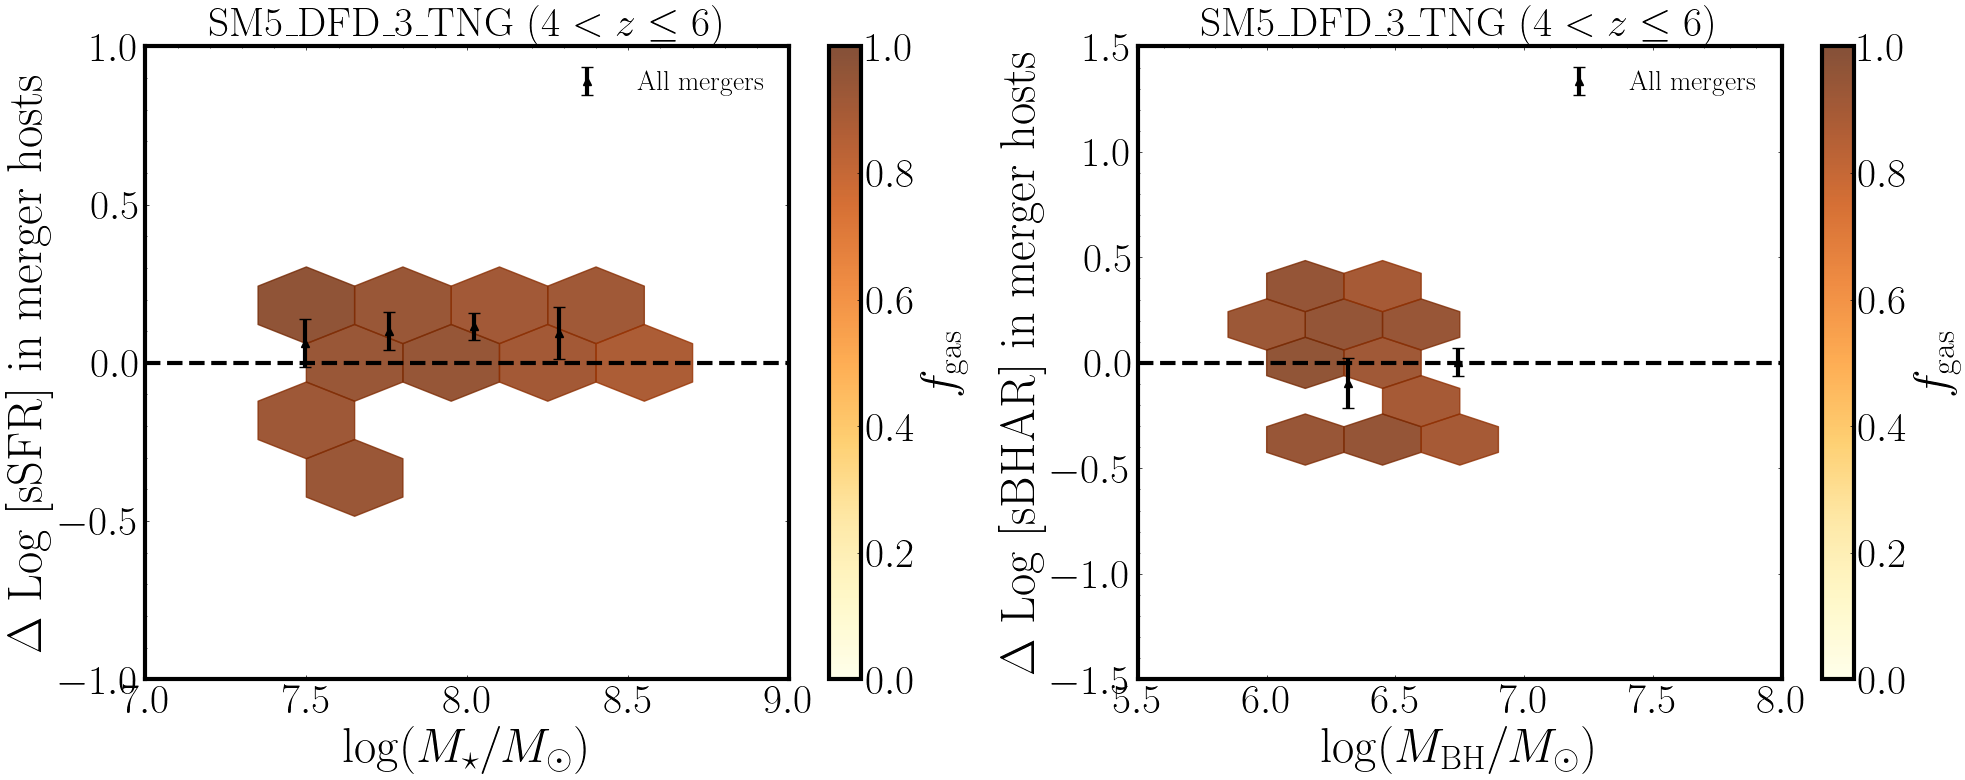

In [8]:
hostplot.set_plot_style(spinewidth=3,linewidth=3, titlesize=30,labelsize=35,xlabelsize=30,ylabelsize=30,legendsize=20,bold=True)

fig,ax = plt.subplots(1,2,figsize=(20,8))

log_Mstar_bins = np.linspace(7,12,20)

sim='SM5_DFD_3_TNG'
z_offset = 0.05
c_major = "#7a0177"   # orange
c_minor = "#c51b8a"   # red
c_all   = "#000000"   # purple
#avg_sSFR_major,std_sSFR_major = utils.enhancement_vs_mstar_for_z(ax,sim_objs[sim],'sSFR',10**log_Mstar_bins,zlow=4,zupper=6,log=True,major_merger_flag=True,min_N=4)
#avg_sSFR_minor,std_sSFR_minor = utils.enhancement_vs_mstar_for_z(ax,sim_objs[sim],'sSFR',10**log_Mstar_bins,zlow=4,zupper=6,log=True,minor_merger_flag=True,min_N=6)
avg_sSFR_all,std_sSFR_all = utils.enhancement_vs_mstar_for_z(ax,sim_objs[sim],'sSFR',10**log_Mstar_bins,zlow=4,zupper=10,log=True,min_N=10)
#ax[0] = make_hex_plot_quantity_vs_stellar_mass(ax[0],sim_objs[sim],quantity='sSFR',zlow=0,zupper=2,gridsize=25,cmap='Blues',xmin=8,xmax=12,ymin=-2,ymax=2,mincnt=1,alpha=0.8)
ax[0] = utils.make_hex_plot_quantity_vs_stellar_mass(
    ax[0], sim_objs[sim], quantity='sSFR', zlow=4, zupper=6,
    gridsize=20, cmap='YlOrBr', xmin=6, xmax=12, ymin=-2, ymax=2,
    mincnt=3, alpha=0.8, color_quantity='fgas',vmin=0,vmax=1
)

#ax[0].errorbar(log_Mstar_bins[:-1]+np.diff(log_Mstar_bins)/2,     avg_sSFR_major, yerr=std_sSFR_major, fmt='o', capsize=4, label='Major mergers', color=c_major, alpha=1)
#ax[0].errorbar(log_Mstar_bins[:-1]+np.diff(log_Mstar_bins)/2+z_offset, avg_sSFR_minor, yerr=std_sSFR_minor, fmt='s', capsize=4, label='Minor mergers', color=c_minor, alpha=1)
ax[0].errorbar(log_Mstar_bins[:-1]+np.diff(log_Mstar_bins)/2+2*z_offset, avg_sSFR_all, yerr=std_sSFR_all, fmt='^', capsize=4, label='All mergers', color=c_all, alpha=1)
ax[0].set_xlabel(r'$\log(M_{\star}/M_{\odot})$')
ax[0].axhline(0,ls='--',color='black')
ax[0].set_ylabel('$\Delta$ Log [sSFR] in merger hosts')
ax[0].set_xlim(7,9)
ax[0].set_ylim(-1,1)
ax[0].legend()
ax[0].set_title(f'{sim} ($4<z\leq6)$')

log_MBH_bins = np.linspace(6,12,15)

#avg_sBHAR_major,std_sBHAR_major = utils.enhancement_vs_mbh_for_z(ax,sim_objs[sim],'sBHAR',10**log_MBH_bins,zlow=4,zupper=6,log=True,major_merger_flag=True,min_N=4)
#avg_sBHAR_minor,std_sBHAR_minor = utils.enhancement_vs_mbh_for_z(ax,sim_objs[sim],'sBHAR',10**log_MBH_bins,zlow=4,zupper=6,log=True,minor_merger_flag=True,min_N=6)
avg_sBHAR_all,std_sBHAR_all = utils.enhancement_vs_mbh_for_z(ax,sim_objs[sim],'sBHAR',10**log_MBH_bins,zlow=4,zupper=12,log=True,min_N=10)

ax[1] = utils.make_hex_plot_quantity_vs_black_hole_mass(
    ax[1], sim_objs[sim], quantity='sBHAR', zlow=4, zupper=12,
    gridsize=20, cmap='YlOrBr', xmin=6, xmax=12, ymin=-2, ymax=2,
    mincnt=3, alpha=0.8, color_quantity='fgas',vmin=0,vmax=1
)

#ax[1].errorbar(log_MBH_bins[:-1]+np.diff(log_MBH_bins)/2,     avg_sBHAR_major, yerr=std_sBHAR_major, fmt='o', capsize=4, label='Major mergers', color=c_major, alpha=1)
#ax[1].errorbar(log_MBH_bins[:-1]+np.diff(log_MBH_bins)/2+z_offset, avg_sBHAR_minor, yerr=std_sBHAR_minor, fmt='s', capsize=4, label='Minor mergers', color=c_minor, alpha=1)
ax[1].errorbar(log_MBH_bins[:-1]+np.diff(log_MBH_bins)/2+2*z_offset, avg_sBHAR_all, yerr=std_sBHAR_all, fmt='^', capsize=4, label='All mergers', color=c_all, alpha=1)
ax[1].set_xlabel(r'$\log(M_{\rm BH}/M_{\odot})$')
ax[1].axhline(0,ls='--',color='black')
ax[1].set_ylabel('$\Delta$ Log [sBHAR] in merger hosts')
ax[1].set_xlim(5.5,8)
ax[1].set_ylim(-1.5,1.5)
ax[1].legend()
ax[1].set_title(f'{sim} ($4<z\leq6)$')

fig.tight_layout()
fig.savefig("../../figures/sSFR_and_sBHAR_enhancements_vs_Mstar_and_MBH_BRAHMA_highz.pdf")

# fgas distribution

In [9]:
TNG_zs,counts_TNG_zs = np.unique(sim_objs['TNG50'].z_merging_pop,return_counts=True)
filtered_TNG_zs = TNG_zs[counts_TNG_zs>=10]
print(filtered_TNG_zs,counts_TNG_zs[counts_TNG_zs>=10])

[0.64464184 1.20625808 1.24847261 1.41409822 1.66666956 1.74357057
 1.90408954 2.00202814 2.10326965 2.20792547 2.31611074 2.4442257
 2.57729027 3.00813107] [11 10 10 18 11 11 18 17 11 10 14 11 22 21]


In [10]:
SM5_zs,counts_SM5_zs = np.unique(sim_objs['SM5_DFD_3_TNG'].z_merging_pop,return_counts=True)
filtered_TNG_zs = SM5_zs[counts_SM5_zs>=10]
print(filtered_TNG_zs,counts_SM5_zs[counts_SM5_zs>=10])

[0.0994018  0.29771768 0.39992696 0.50304752 0.70010635 0.99729423
 1.49551217 2.00202814 3.00813107 4.00794511 4.99593347 6.0107574 ] [10 21 12 29 60 80 59 94 71 41 28 11]


In [11]:
def find_fgas_mergers_and_controls(sim_obj, z, z_tol=0.25):
    # Select mergers and controls near redshift z
    merger_mask = np.abs(sim_obj.z_merging_pop - z) < z_tol
    control_mask = np.abs(sim_obj.z_control_pop - z) < z_tol
    fgas_merger = sim_obj.fgas_progs[merger_mask]
    fgas_control = sim_obj.fgas_control[control_mask]
    return fgas_merger, fgas_control

TNG50 z~1 merger: median=0.270, std=0.209, N=89
TNG50 z~1 control: median=0.135, std=0.183, N=90
TNG50 z~2 merger: median=0.489, std=0.234, N=65
TNG50 z~2 control: median=0.244, std=0.213, N=65
TNG50 z~3 merger: median=0.348, std=0.273, N=22
TNG50 z~3 control: median=0.151, std=0.227, N=22
SM5_DFD_3_TNG z~4 merger: median=0.915, std=0.047, N=41
SM5_DFD_3_TNG z~4 control: median=0.814, std=0.110, N=41
SM5_DFD_3_TNG z~5 merger: median=0.938, std=0.032, N=28
SM5_DFD_3_TNG z~5 control: median=0.867, std=0.075, N=28
SM5_DFD_3_TNG z~6 merger: median=0.953, std=0.040, N=11
SM5_DFD_3_TNG z~6 control: median=0.867, std=0.064, N=11


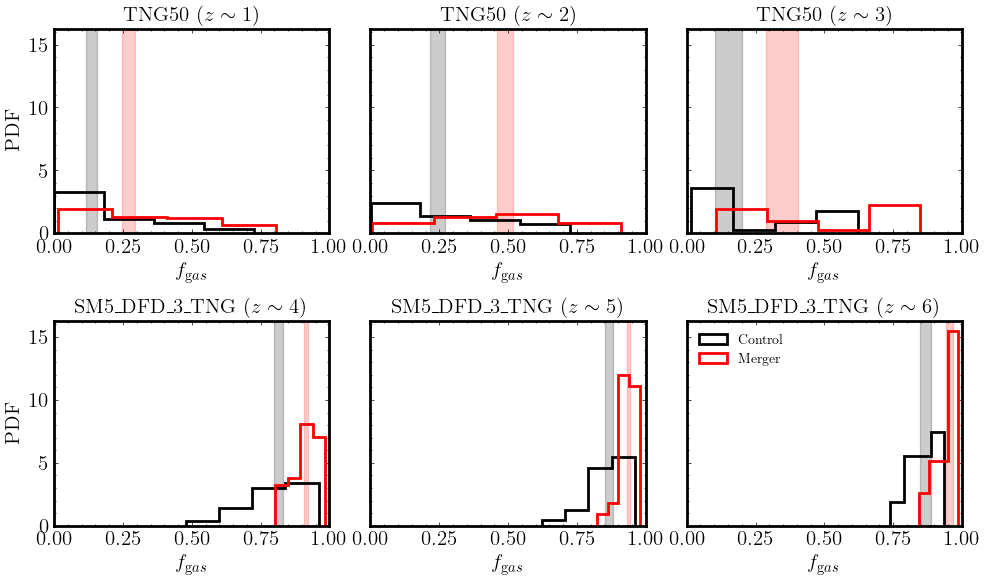

In [12]:
hostplot.set_plot_style(spinewidth=2,linewidth=3, titlesize=15,labelsize=15,xlabelsize=15,ylabelsize=15,legendsize=10,bold=True)
fig, axes = plt.subplots(2,3, figsize=(10,6),sharey=True)

z_TNG = [1,2,3]

#plot TNG f-gas distributions 
for i,z in enumerate(z_TNG):
    ax = axes[0,i]
    fgas_merger,fgas_control = find_fgas_mergers_and_controls(sim_objs['TNG50'], z)
    merger_bins = np.linspace(np.min(fgas_merger),np.max(fgas_merger),5)
    control_bins = np.linspace(np.min(fgas_control),np.max(fgas_control),5)
    ax.hist(fgas_control, bins=control_bins, density=True, label='Control', color='black',histtype='step',linewidth=2)
    ax.hist(fgas_merger, bins=merger_bins, density=True, label='Merger', color='red',histtype='step',linewidth=2)
    
    # Median and standard error for merger
    if len(fgas_merger) > 0:
        median_merger = np.median(fgas_merger)
        stderr_merger = np.std(fgas_merger, ddof=1) / np.sqrt(len(fgas_merger))
        std_merger = np.std(fgas_merger, ddof=1)
        ax.axvspan(median_merger-stderr_merger, median_merger+stderr_merger, color='red', alpha=0.2)
        print(f"TNG50 z~{z} merger: median={median_merger:.3f}, std={std_merger:.3f}, N={len(fgas_merger)}")
    # Median and standard error for control
    if len(fgas_control) > 0:
        median_control = np.median(fgas_control)
        stderr_control = np.std(fgas_control, ddof=1) / np.sqrt(len(fgas_control))
        std_control = np.std(fgas_control, ddof=1)
        ax.axvspan(median_control-stderr_control, median_control+stderr_control, color='black', alpha=0.2)
        print(f"TNG50 z~{z} control: median={median_control:.3f}, std={std_control:.3f}, N={len(fgas_control)}")

    
    ax.set_title(f'TNG50 ($z\sim{z})$')
    ax.set_xlabel('$f_{\mathrm gas}$')
    ax.set_xlim(0,1)
    if i == 0:
        ax.set_ylabel('PDF')
        
#plot BRAHMA f-gas distributions 

z_BRAHMA = [4,5,6]
for i,z in enumerate(z_BRAHMA):
    ax = axes[1,i]
    fgas_merger,fgas_control = find_fgas_mergers_and_controls(sim_objs['SM5_DFD_3_TNG'], z)
    merger_bins = np.linspace(np.min(fgas_merger),np.max(fgas_merger),5)
    control_bins = np.linspace(np.min(fgas_control),np.max(fgas_control),5)
    ax.hist(fgas_control, bins=control_bins, density=True, label='Control', color='black',histtype='step',linewidth=2)
    ax.hist(fgas_merger, bins=merger_bins, density=True, label='Merger', color='red',histtype='step',linewidth=2)
    
    # Median and standard error for merger
    if len(fgas_merger) > 0:
        median_merger = np.median(fgas_merger)
        stderr_merger = np.std(fgas_merger, ddof=1) / np.sqrt(len(fgas_merger))
        std_merger = np.std(fgas_merger, ddof=1)
        ax.axvspan(median_merger-stderr_merger, median_merger+stderr_merger, color='red', alpha=0.2)
        print(f"SM5_DFD_3_TNG z~{z} merger: median={median_merger:.3f}, std={std_merger:.3f}, N={len(fgas_merger)}")
    # Median and standard error for control
    if len(fgas_control) > 0:
        median_control = np.median(fgas_control)
        stderr_control = np.std(fgas_control, ddof=1) / np.sqrt(len(fgas_control))
        std_control = np.std(fgas_control, ddof=1)
        ax.axvspan(median_control-stderr_control, median_control+stderr_control, color='black', alpha=0.2)
        print(f"SM5_DFD_3_TNG z~{z} control: median={median_control:.3f}, std={std_control:.3f}, N={len(fgas_control)}")

    
    ax.set_title(f'SM5_DFD_3_TNG ($z\sim{z})$')
    ax.set_xlabel('$f_{\mathrm gas}$')
    if i == 0:
        ax.set_ylabel('PDF')
        
    if i==2:
        ax.legend()
    ax.set_xlim(0,1)

fig.tight_layout()
fig.savefig("../../fgas-mergers-and-controls-dist-across-zs.pdf")

In [56]:
def sSFR_enhancement_vs_fgas(sim_obj, z, z_tol=0.25, fgas_bins=np.linspace(0, 1, 6)):
    # Select mergers and controls near redshift z
    merger_mask = np.abs(sim_obj.z_merging_pop - z) < z_tol
    control_mask = np.abs(sim_obj.z_control_pop - z) < z_tol
    fgas_merger = sim_obj.fgas_progs[merger_mask]
    fgas_control = sim_obj.fgas_control[control_mask]
    sSFR_merger = sim_obj.sSFR_merging_pop[merger_mask]
    sSFR_control = sim_obj.sSFR_control_pop[control_mask]
    
    # Bin by fgas and calculate enhancement in each bin
    enhancement_means = []
    for i in range(len(fgas_bins)-1):
        merger_bin_mask = (fgas_merger >= fgas_bins[i]) & (fgas_merger < fgas_bins[i+1])
        control_bin_mask = (fgas_control >= fgas_bins[i]) & (fgas_control < fgas_bins[i+1])
        
        if np.sum(merger_bin_mask) > 0 and np.sum(control_bin_mask) > 0:
            # Filter out zero/negative values before taking log
            sSFR_merger_bin = sSFR_merger[merger_bin_mask]
            sSFR_control_bin = sSFR_control[control_bin_mask]
            
            # Filter each array independently
            sSFR_merger_valid = sSFR_merger_bin[sSFR_merger_bin > 0]
            sSFR_control_valid = sSFR_control_bin[sSFR_control_bin > 0]
            
            if len(sSFR_merger_valid) > 0 and len(sSFR_control_valid) > 0:
                sSFR_merger_log = np.log10(sSFR_merger_valid)
                sSFR_control_log = np.log10(sSFR_control_valid)
                enhancement = np.mean(sSFR_merger_log) - np.mean(sSFR_control_log)
                enhancement_means.append(enhancement)
            else:
                enhancement_means.append(np.nan)
        else:
            enhancement_means.append(np.nan)
    
    return fgas_bins[:-1] + np.diff(fgas_bins)/2, enhancement_means

[0.00129245 0.00204839 0.00324648 0.00514532 0.00815479 0.01292447
 0.0204839  0.03246479 0.05145323 0.08154787 0.12924466 0.20483898
 0.32464791 0.51453226 0.81547867] [nan, nan, nan, 0.4786505707969262, nan, nan, nan, 0.471848711154637, -0.6035990345660132, -0.28392763114966435, -0.3673422667988273, -0.15086632692089985, -0.21693094879762498, 0.19563473334693882, nan]
[0.00129245 0.00204839 0.00324648 0.00514532 0.00815479 0.01292447
 0.0204839  0.03246479 0.05145323 0.08154787 0.12924466 0.20483898
 0.32464791 0.51453226 0.81547867] [nan, nan, nan, -1.2219153904518993, 0.4960864761070525, nan, nan, 0.6049483698350127, -0.45999467912344194, -0.2971523217862302, -0.44215922202024416, -0.05406253980908815, -0.19837807730581858, 0.20237079997682805, nan]
[0.00129245 0.00204839 0.00324648 0.00514532 0.00815479 0.01292447
 0.0204839  0.03246479 0.05145323 0.08154787 0.12924466 0.20483898
 0.32464791 0.51453226 0.81547867] [nan, nan, nan, -1.032608282430708, 0.6541383957795297, nan, nan, -

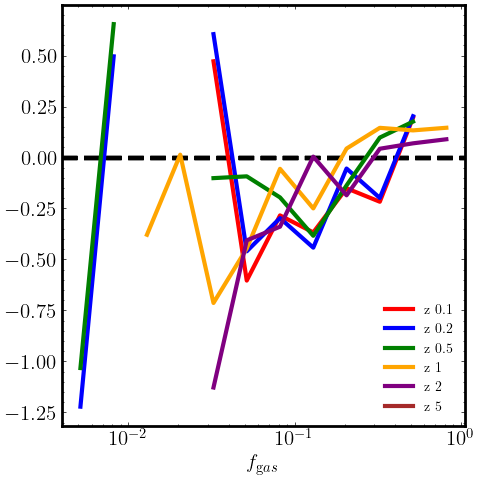

In [64]:
z_TNG = [0.1,0.2,0.5,1,2,5]
z_colors = ['red','blue', 'green', 'orange', 'purple', 'brown']
fig, ax = plt.subplots(1,1, figsize=(5,5),sharey=True)
fgas_bins = np.logspace(-3, 0, 16)  # Logarithmic bins from 0.001 to 1

for i,z in enumerate(z_TNG):
    fgas_bin_centers, enhancement_means= sSFR_enhancement_vs_fgas(sim_objs['TNG50'], z, fgas_bins=fgas_bins)
    print(fgas_bin_centers, enhancement_means)
    ax.errorbar(fgas_bin_centers, enhancement_means, fmt='-', color=z_colors[i], capsize=5,label=f'z~{z}')
    ax.axhline(0, ls='--', color='black')
    ax.set_xlabel('$f_{\mathrm gas}$')
    # if i == 0:
    #     ax.set_ylabel('sSFR Enhancement (Merger - Control)')
    # ax.set_title(f'TNG50 ($z\sim{z})$')
    # ax.set_xlim(0,1)
ax.set_xscale('log',base=10)
ax.legend()
fig.tight_layout()